Notebook to determine copy correction procedure from toy example. 

1. Start with toy example of fully synchronized reads. Show that we can transform from the equal total read count matrix to the copy number matrix.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Real data example, Chromosome X, Replicate 1

Now, we will see if this workflow is resilient to the real data. Note that changes need to be made to the deconvolution process, as the indices in the deconvolution profile are different:
- We need to enforce continuity between RG1/CG1 and PostG1
- Replication timing can only exist in PostG1 (possibly only in S-phase).


In [349]:
from src.RealDataReplication import RealDataReplicationDeconvolution

real_deconv = RealDataReplicationDeconvolution()


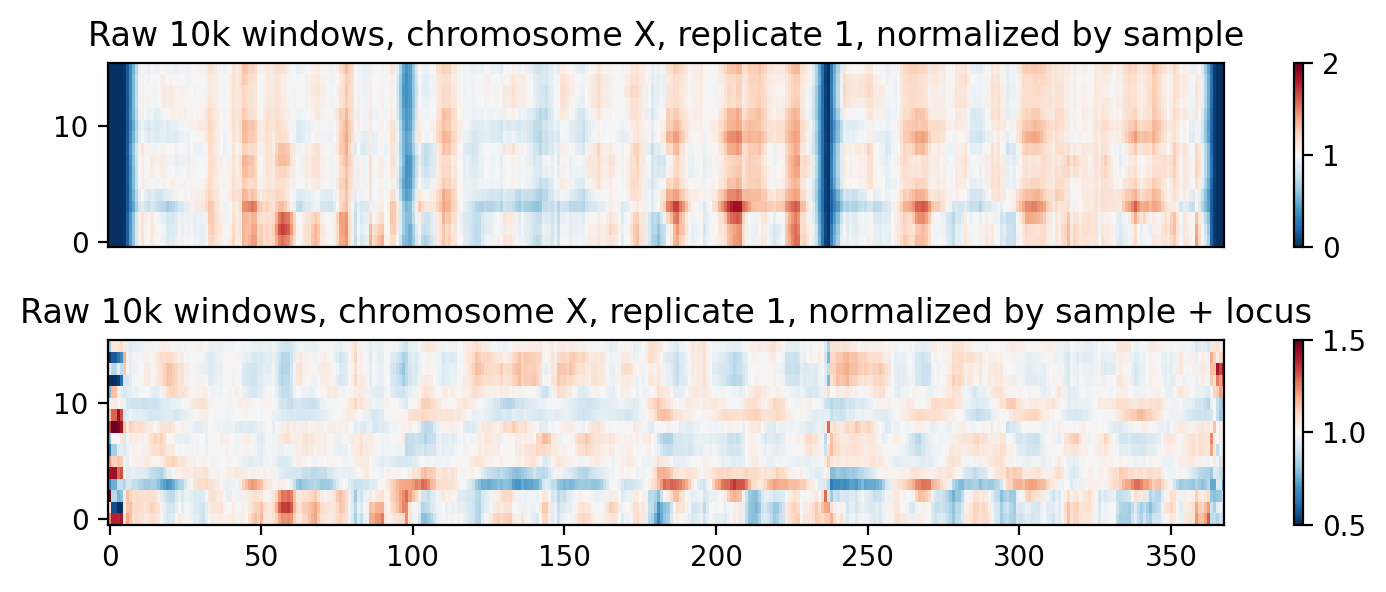

In [487]:
plt.figure(figsize=(9, 3))
plt.subplot(2, 1, 1)
plt.imshow(real_deconv.normalized_occupancy.T, origin='lower', aspect='auto', vmin=0, vmax=2,
          cmap='RdBu_r')
plt.xticks([])
plt.title("Raw 10k windows, chromosome X, replicate 1, normalized by sample")
plt.colorbar()

plt.subplot(2, 1, 2)

normalized_by_columns = real_deconv.normalized_occupancy / real_deconv.normalized_occupancy.mean(axis=1).values.reshape((-1, 1))

plt.imshow(normalized_by_columns.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.5,
          cmap='RdBu_r')
plt.title("Raw 10k windows, chromosome X, replicate 1, normalized by sample + locus")
plt.subplots_adjust(hspace=0.5)
plt.colorbar()

Notable observation, the raw 10kb counts, when normalized by samples has places in the genome with many more reads than other locations.

If we are only concerned about copy number duplication, then perhaps it is reasonable to scale the genomic locii to the same general values... We are only concerned with count doubling at each location....

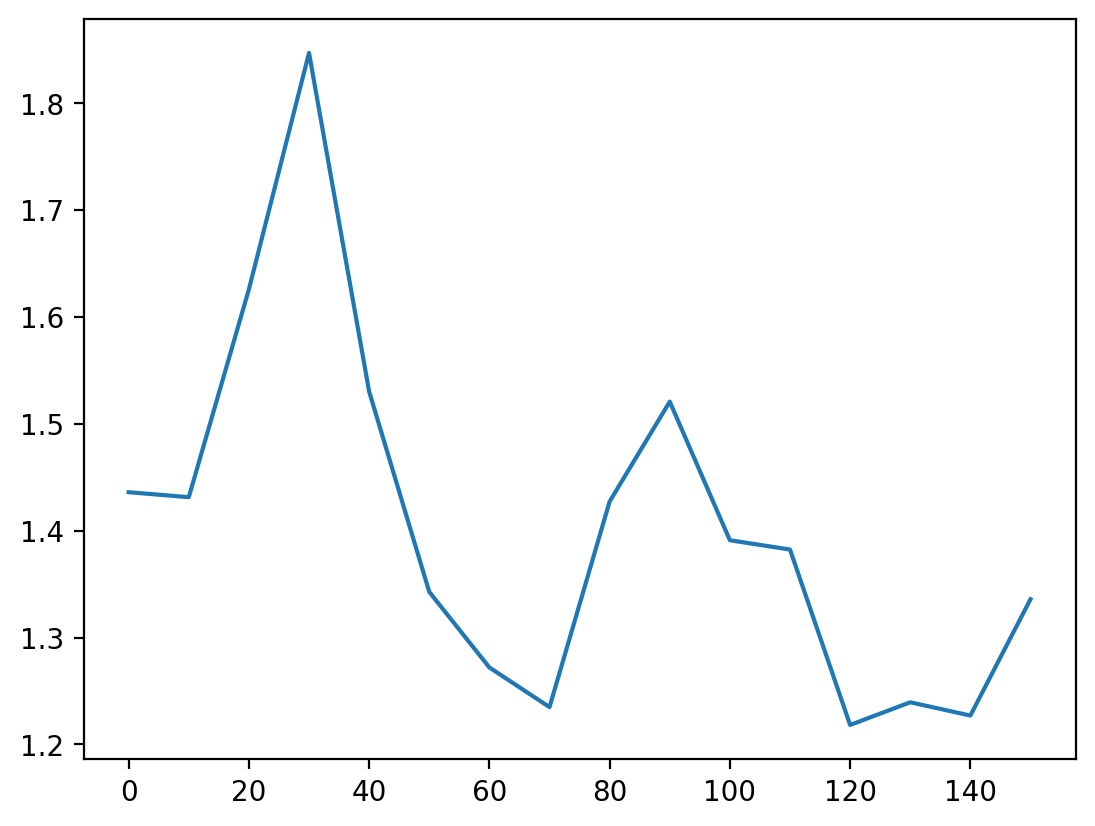

In [485]:
plt.plot(real_deconv.normalized_occupancy.loc[414000])

(16, 87)

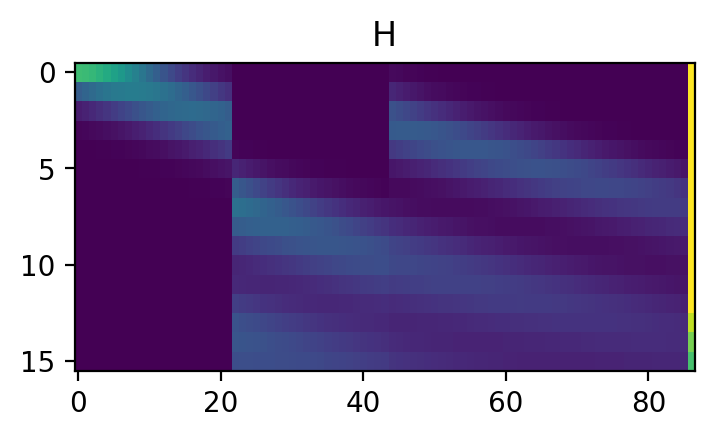

In [397]:
from src.config import load_configs_by_config_type

# Load the config for replicate 1
config, _ = load_configs_by_config_type('shared')
H, _ = config.calcH_function(config.intervals_wt1, config.WT1_TIMEPOINTS)
plt.figure(figsize=(4, 2))
plt.imshow(H, vmax=0.1, aspect='auto')
plt.title("H")
H.shape

Text(0.5, 1.0, 'Example curves\nnormalized by sample+column')

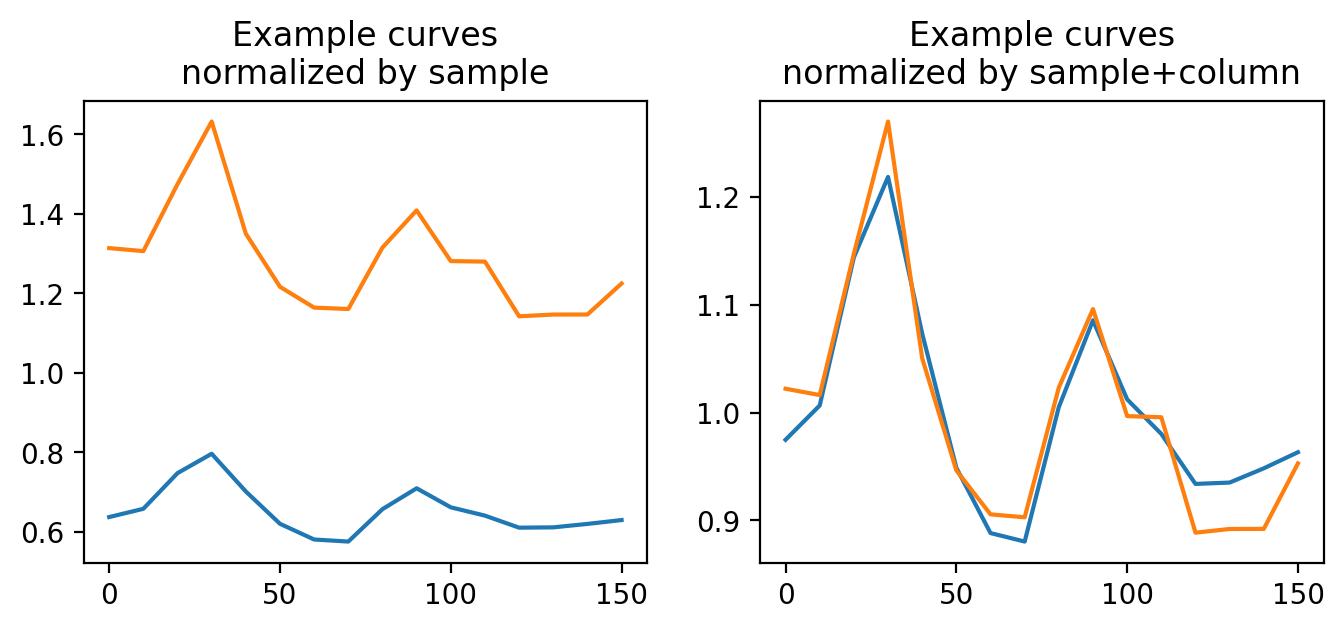

In [400]:
example_g_1 = real_deconv.normalized_occupancy.iloc[100]
example_g_2 = real_deconv.normalized_occupancy.iloc[-100]

normalized_example_g_1 = normalized_by_columns.iloc[100]
normalized_example_g_2 = normalized_by_columns.iloc[-100]

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(example_g_1)
plt.plot(example_g_2)
plt.title("Example curves\nnormalized by sample")

plt.subplot(1, 2, 2)
plt.plot(normalized_example_g_1)
plt.plot(normalized_example_g_2)
plt.title("Example curves\nnormalized by sample+column")

In [451]:
CG1_indices = config.get_Hpositions_for_phase('CG1')
RG1_indices = config.get_Hpositions_for_phase('RG1')
postG1_indices = config.get_Hpositions_for_phase('postG1')

# CG1 and RG1 should be 1 throughout
# postG1 should be continuous and end with 0.5
from src.RealDataReplication import deconvolve_avg_copy_curve

n, m = H.shape

num_indices = len(postG1_indices)
rns = np.zeros(num_indices)
avg_curves = np.zeros((num_indices, m))
all_fs = np.zeros((num_indices, m))
all_predicted_gs = np.zeros((num_indices, n))

for i, replication_idx in enumerate(postG1_indices):
    rn, f, inv_learned_avg, predicted_g \
        = deconvolve_avg_copy_curve(normalized_example_g_1, config, H, replication_idx)
    rns[i] = rn
    all_fs[i] = f
    all_predicted_gs[i] = predicted_g
    avg_curves[i] = inv_learned_avg


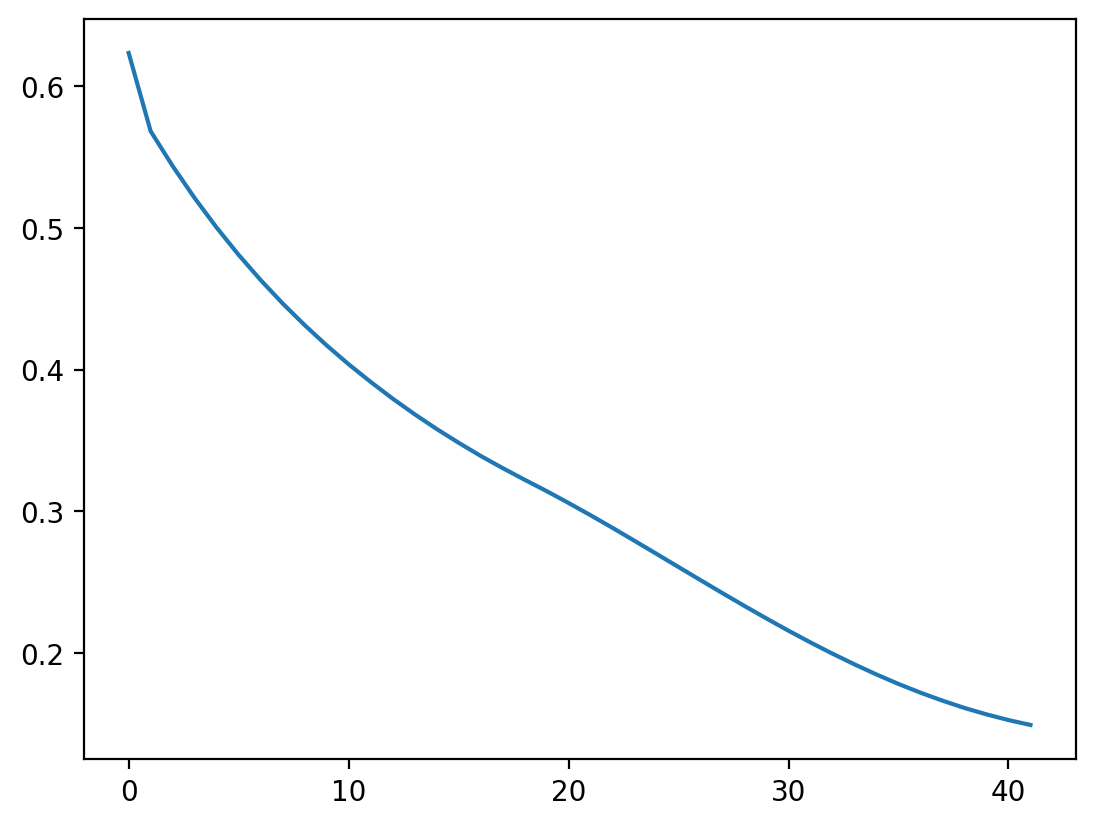

In [452]:
plt.plot(rns)

0

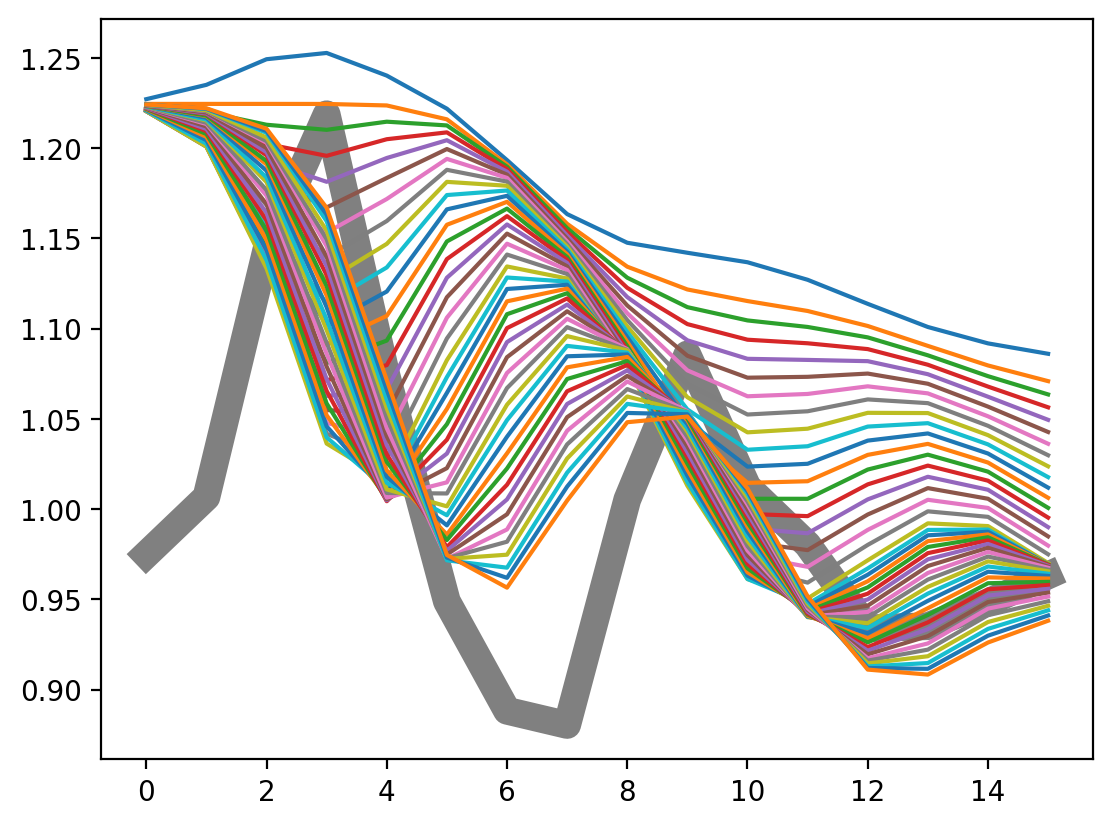

In [453]:
plt.plot(all_predicted_gs.T)
plt.plot(normalized_example_g_1.values, c='gray', lw=10, zorder=0)
0

0

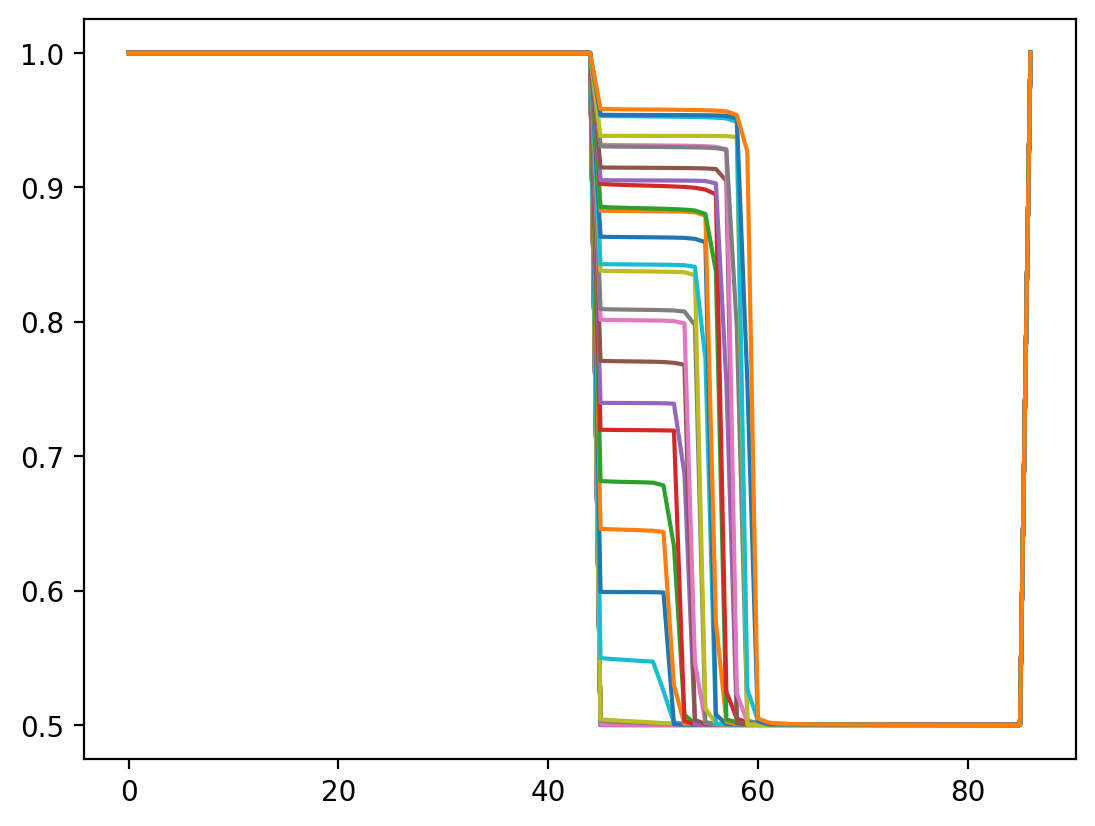

In [454]:
plt.plot(avg_curves.T)
0

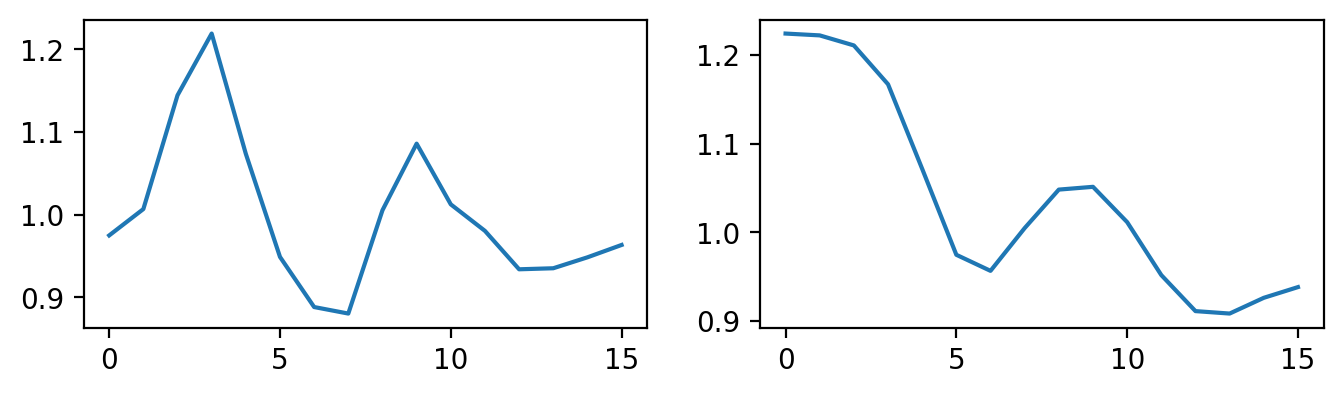

In [455]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
plt.plot(normalized_example_g_1.values)
plt.subplot(1, 2, 2)
plt.plot(predicted_g)

In [ ]:
# There are some assumptions to work through to understand why the fit
# isn't finding a proper average copy number curve.
#    1. The scale of the input G vector
#    2. The expected average copy number curve
#
# We can examine this in the toy example.
#   1. Modify H and G to the RG1/CG1/PostG1 type model
